#PREDECIR PRECIO DEL CARRO USADO

In [ ]:
#Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
import pandas as pd

**1. PREPARACIÓN DE DATOS**

In [ ]:
#Cargamos los datos
data = pd.read_csv("DF_carros_usados.csv")
data.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,price
0,i3,2014,Automatic,34539,Hybrid,0,470.8,0.6,BMW,14495
1,i3,2014,Automatic,37161,Hybrid,0,470.8,0.6,BMW,14182
2,i3,2014,Automatic,42479,Hybrid,0,470.8,0.6,BMW,15450
3,i3,2015,Automatic,9886,Hybrid,0,470.8,0.6,BMW,17481
4,i3,2015,Automatic,33931,Hybrid,0,470.8,0.6,BMW,15498


In [ ]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         26306 non-null  object 
 1   year          26306 non-null  int64  
 2   transmission  26306 non-null  object 
 3   mileage       26306 non-null  int64  
 4   fuelType      26306 non-null  object 
 5   tax           26306 non-null  int64  
 6   mpg           26306 non-null  float64
 7   engineSize    26306 non-null  float64
 8   brand         26306 non-null  object 
 9   price         26306 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 2.0+ MB


In [ ]:
#Descripción de variables numéricas
data.describe()

,year,mileage,tax,mpg,engineSize,price
count,26306.000000,26306.000000,26306.000000,26306.000000,26306.000000,26306.000000
mean,2017.094997,24472.955143,127.446210,53.663275,1.948962,20956.602068
std,2.193072,23233.475431,63.374829,22.494390,0.590230,11442.734159
min,1998.000000,1.000000,0.000000,5.500000,0.600000,1200.000000
25%,2016.000000,6000.000000,125.000000,43.500000,1.500000,13300.000000
50%,2017.000000,18297.500000,145.000000,51.400000,2.000000,18511.500000
75%,2019.000000,35720.750000,145.000000,60.100000,2.000000,26000.000000
max,2020.000000,214000.000000,580.000000,470.800000,6.600000,145000.000000


1.1 DESCRIPCION VARIABLES NUMERICAS

<Axes: >

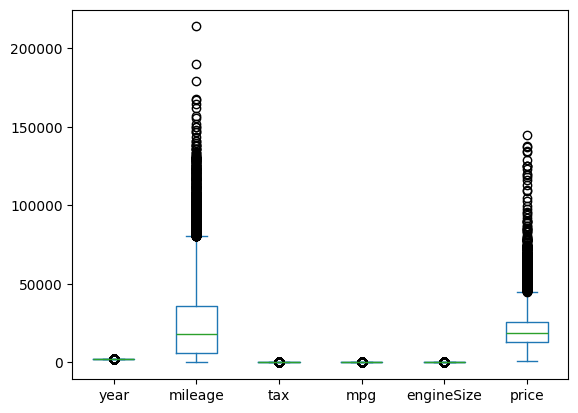

In [ ]:
data.plot(kind='box')

<Axes: >

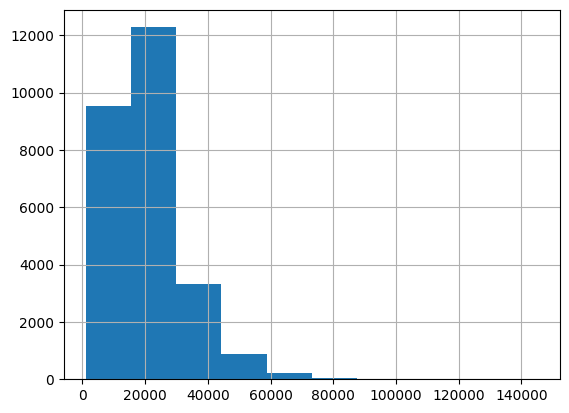

In [ ]:
#Descripción variables numerica a predecir
data['price'].hist()

1.2 DESCRIPCION VARIABLES CATEGORICAS

<Axes: xlabel='model'>

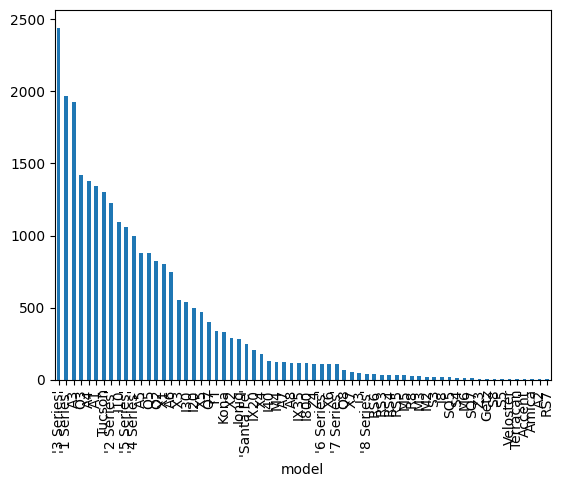

In [ ]:
#Descripción variables categóricas
data['model'].value_counts().plot(kind='bar')

<Axes: xlabel='transmission'>

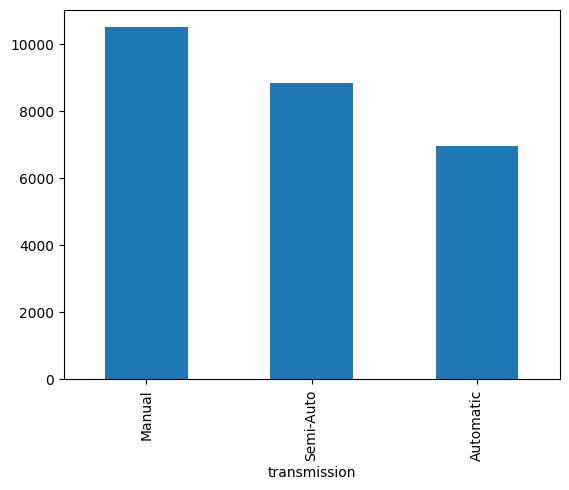

In [ ]:
#Descripción variables categóricas
data['transmission'].value_counts().plot(kind='bar')

<Axes: xlabel='fuelType'>

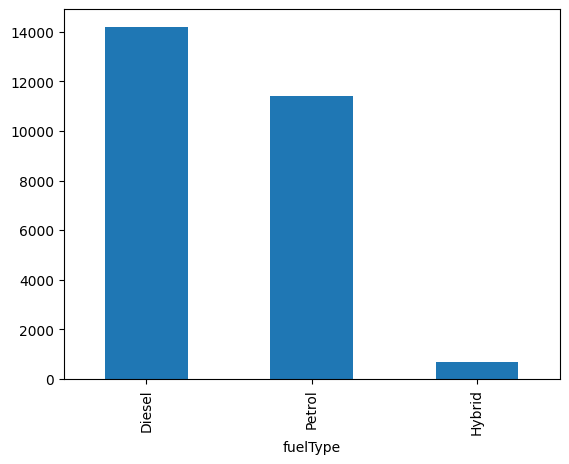

In [ ]:
#Descripción variables categóricas
data['fuelType'].value_counts().plot(kind='bar')

<Axes: xlabel='brand'>

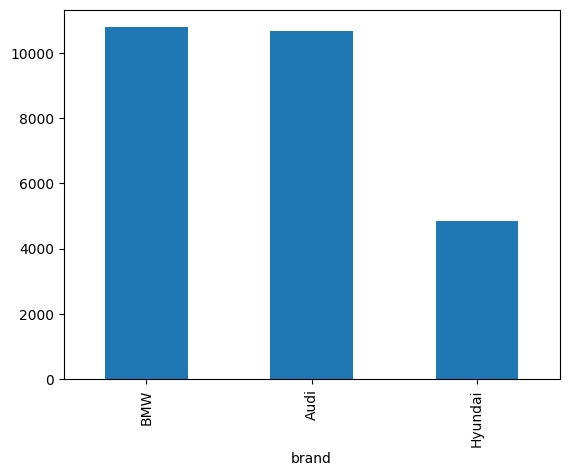

In [ ]:
#Descripción variables categóricas
data['brand'].value_counts().plot(kind='bar')

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
# Cargar librería para Profiling
from pandas_profiling import ProfileReport
from google.colab import files

profile_data=ProfileReport(data, minimal=False) # minimal=True
# Guardar en archivo HTML
profile_data.to_file("reporte_carros.html")
files.download("reporte_carros.html")
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 25.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df= data.copy()   #Sacando copia al df
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,price
0,i3,2014,Automatic,34539,Hybrid,0,470.8,0.6,BMW,14495
1,i3,2014,Automatic,37161,Hybrid,0,470.8,0.6,BMW,14182
2,i3,2014,Automatic,42479,Hybrid,0,470.8,0.6,BMW,15450
3,i3,2015,Automatic,9886,Hybrid,0,470.8,0.6,BMW,17481
4,i3,2015,Automatic,33931,Hybrid,0,470.8,0.6,BMW,15498


**CONFIGURACION DE VARIABLES**


In [ ]:
#Configuración de variables
objetivo = 'price'
predictoras_numericas = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
predictoras_categoricas_multicat = ['brand', 'transmission', 'fuelType', 'model']

# transmission: 3 categorías
# fuelType:     3 categorías
# brand:        3 categorías
# model:        66 categorías ← ojo, genera muchas columnas

**CREACION DE DUMMIES**

In [ ]:
#Creamos variables dummy para convertir  las categorías a números

# Multicat (3+ categorías): drop_first=False → conserva todas las categorías
df = pd.get_dummies(df, columns=predictoras_categoricas_multicat, drop_first=False, dtype=int)
#df = pd.get_dummies(df, columns=predictoras_categoricas_2cat, drop_first=True, dtype=int)     #No existen variables categorias de 2
df.head()

# No hay LabelEncoder → Variable objetivo 'price' ya es numérica
df.head()

,year,mileage,tax,mpg,engineSize,price,brand_Audi,brand_BMW,brand_Hyundai,transmission_Automatic,...,model_X2,model_X3,model_X4,model_X5,model_X6,model_X7,model_Z3,model_Z4,model_i3,model_i8
0,2014,34539,0,470.8,0.6,14495,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
1,2014,37161,0,470.8,0.6,14182,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2014,42479,0,470.8,0.6,15450,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,2015,9886,0,470.8,0.6,17481,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
4,2015,33931,0,470.8,0.6,15498,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0


**NORMALIZACION DE VARIABLES NUMERICAS**

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()   #Se crear el objeto normalizador

min_max_scaler.fit(df[predictoras_numericas]) #Ajuste de los parametros: max - min
df[predictoras_numericas]= min_max_scaler.transform(df[predictoras_numericas]) #Transformar y reemplazar en el dataframe
df.head()

,year,mileage,tax,mpg,engineSize,price,brand_Audi,brand_BMW,brand_Hyundai,transmission_Automatic,...,model_X2,model_X3,model_X4,model_X5,model_X6,model_X7,model_Z3,model_Z4,model_i3,model_i8
0,0.727273,0.161393,0.0,1.0,0.0,14495,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0.727273,0.173646,0.0,1.0,0.0,14182,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0.727273,0.198496,0.0,1.0,0.0,15450,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,0.772727,0.046192,0.0,1.0,0.0,17481,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0.772727,0.158552,0.0,1.0,0.0,15498,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0


**2. VALIDACIÓN CRUZADA**

In [ ]:
#Validación Cruzada
from sklearn.model_selection import cross_validate

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()

#Medidas de evaluación
scoring=('neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error')

#Muestreo lineal
cv=10

#Se separa variables predictoras y objetivo
X = df.drop(objetivo, axis = 1)
Y = df[objetivo]
#X.info()
print(f'X: {X.shape} | Y: {Y.shape}')
print('Config validación cruzada')

X: (26306, 80) | Y: (26306,)
Config validación cruzada


3. SACANDO EL MEJOR MODELO

3.1 Modelo Tree

In [ ]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=7, max_depth=None)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
#print('scores: ',scores)


# Promedios para verificar overfitting comparando medidas en train y test
print('scores mean: ',scores.mean())
#Cuidado overfitting, más de 5 puntos de diferencia
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_neg_mean_absolute_error']
comparacion_CV


scores mean:  fit_time                                    2.706400e-01
score_time                                  9.601212e-03
test_neg_mean_absolute_error               -4.082926e+03
train_neg_mean_absolute_error              -1.277033e+03
test_neg_mean_squared_error                -4.292023e+07
train_neg_mean_squared_error               -5.069535e+06
test_neg_root_mean_squared_error           -5.746495e+03
train_neg_root_mean_squared_error          -2.248564e+03
test_neg_mean_absolute_percentage_error    -2.042327e-01
train_neg_mean_absolute_percentage_error   -6.399828e-02
dtype: float64


,Tree
0,-4125.489197
1,-2580.613467
2,-3137.414773
3,-4034.826870
4,-3645.782038
5,-3088.803260
6,-2465.741008
7,-1888.765689
8,-7108.752916
9,-8753.071193


3.2 Random Forest

In [ ]:
#Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(n_estimators=100, max_samples=0.8, criterion='squared_error', min_samples_leaf=2, max_depth=None)


scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,29.231287,0.090020,-4022.557502,-900.631030,-2.683205e+07,-2.373909e+06,-5179.966093,-1540.749424,-0.433720,-0.043263
1,24.508146,0.098714,-2289.079617,-879.658029,-9.739690e+06,-2.464414e+06,-3120.847593,-1569.845357,-0.128393,-0.043991
2,24.417125,0.096735,-2675.355969,-874.537088,-1.880154e+07,-2.468281e+06,-4336.074659,-1571.076367,-0.157700,-0.043775
3,25.954851,0.107483,-2641.002112,-877.183366,-1.364536e+07,-2.426661e+06,-3693.963265,-1557.774355,-0.153341,-0.043300
4,29.654793,0.259310,-3237.869128,-835.749276,-1.737988e+07,-2.323799e+06,-4168.918668,-1524.401268,-0.132878,-0.043286
5,23.421386,0.104774,-2497.784057,-844.131537,-1.057518e+07,-2.336993e+06,-3251.950563,-1528.722709,-0.113732,-0.043308
6,23.957887,0.115190,-2274.851983,-863.454016,-1.006582e+07,-2.418604e+06,-3172.668160,-1555.186082,-0.111254,-0.043207
7,24.356097,0.112801,-1404.142598,-875.659278,-3.600346e+06,-2.451861e+06,-1897.457776,-1565.841997,-0.088985,-0.043264
8,23.850324,0.091377,-6402.134619,-810.228450,-1.002184e+08,-1.746927e+06,-10010.916374,-1321.713669,-0.190041,-0.042985
9,27.333069,0.079102,-6942.303492,-814.333965,-1.084030e+08,-2.093579e+06,-10411.673887,-1446.920671,-0.222884,-0.043048


In [ ]:
# Promedios para verificar overfitting
print('scores mean RF:', scores.mean())
# Cuidado overfitting, más de 5 puntos de diferencia

# Guardar para comparación
comparacion_CV['RF'] = scores['test_neg_mean_absolute_error']
comparacion_CV

scores mean RF: fit_time                                    2.566850e+01
score_time                                  1.155506e-01
test_neg_mean_absolute_error               -3.438708e+03
train_neg_mean_absolute_error              -8.575566e+02
test_neg_mean_squared_error                -3.192613e+07
train_neg_mean_squared_error               -2.310503e+06
test_neg_root_mean_squared_error           -4.924444e+03
train_neg_root_mean_squared_error          -1.518223e+03
test_neg_mean_absolute_percentage_error    -1.732927e-01
train_neg_mean_absolute_percentage_error   -4.334258e-02
dtype: float64


,Tree,RF
0,-4125.489197,-4022.557502
1,-2580.613467,-2289.079617
2,-3137.414773,-2675.355969
3,-4034.826870,-2641.002112
4,-3645.782038,-3237.869128
5,-3088.803260,-2497.784057
6,-2465.741008,-2274.851983
7,-1888.765689,-1404.142598
8,-7108.752916,-6402.134619
9,-8753.071193,-6942.303492


3.3  Modelo KNN

In [ ]:
#KNN
#Nota: ya normalizamos las variables numéricas al inicio, no se repite
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=7, metric='euclidean')

scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)

print('scores mean KNN:')
print(scores.mean())
# Cuidado overfitting, más de 5 puntos de diferencia

comparacion_CV['KNN'] = scores['test_neg_mean_absolute_error']
comparacion_CV

scores mean KNN:
fit_time                                    2.982914e-02
score_time                                  6.925126e-01
test_neg_mean_absolute_error               -3.871372e+03
train_neg_mean_absolute_error              -1.424358e+03
test_neg_mean_squared_error                -4.096461e+07
train_neg_mean_squared_error               -6.385706e+06
test_neg_root_mean_squared_error           -5.531412e+03
train_neg_root_mean_squared_error          -2.521748e+03
test_neg_mean_absolute_percentage_error    -1.915126e-01
train_neg_mean_absolute_percentage_error   -7.352289e-02
dtype: float64


,Tree,RF,KNN
0,-4125.489197,-4022.557502,-2461.780366
1,-2580.613467,-2289.079617,-2600.421133
2,-3137.414773,-2675.355969,-2944.160124
3,-4034.826870,-2641.002112,-3918.168486
4,-3645.782038,-3237.869128,-4390.103328
5,-3088.803260,-2497.784057,-3407.819026
6,-2465.741008,-2274.851983,-2305.799348
7,-1888.765689,-1404.142598,-1806.949593
8,-7108.752916,-6402.134619,-7010.047311
9,-8753.071193,-6942.303492,-7868.474362


3.4 Modelo NN (Red Neuronal)

In [ ]:
# ── Red Neuronal ─────────────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(
    activation='relu',
    hidden_layer_sizes=(200),
    learning_rate='adaptive',
    learning_rate_init=0.7,
    momentum=0.3,
    max_iter=500,
    verbose=False,
    random_state=42
)

scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)

print('scores mean NN:')
print(scores.mean())
# Cuidado overfitting, más de 5 puntos de diferencia

comparacion_CV['NN'] = scores['test_neg_mean_absolute_error']
comparacion_CV

scores mean NN:
fit_time                                    2.659179e+01
score_time                                  1.146250e-02
test_neg_mean_absolute_error               -2.848874e+03
train_neg_mean_absolute_error              -1.573693e+03
test_neg_mean_squared_error                -2.148865e+07
train_neg_mean_squared_error               -6.212482e+06
test_neg_root_mean_squared_error           -4.170572e+03
train_neg_root_mean_squared_error          -2.490587e+03
test_neg_mean_absolute_percentage_error    -1.507714e-01
train_neg_mean_absolute_percentage_error   -7.792002e-02
dtype: float64


,Tree,RF,KNN,NN
0,-4125.489197,-4022.557502,-2461.780366,-3272.586372
1,-2580.613467,-2289.079617,-2600.421133,-1652.190473
2,-3137.414773,-2675.355969,-2944.160124,-2092.378808
3,-4034.826870,-2641.002112,-3918.168486,-2955.812280
4,-3645.782038,-3237.869128,-4390.103328,-2667.965215
5,-3088.803260,-2497.784057,-3407.819026,-2129.092245
6,-2465.741008,-2274.851983,-2305.799348,-2136.836132
7,-1888.765689,-1404.142598,-1806.949593,-1495.942447
8,-7108.752916,-6402.134619,-7010.047311,-5375.546219
9,-8753.071193,-6942.303492,-7868.474362,-4710.388634


3.5 SVR

In [ ]:
#SVR
from sklearn.svm import SVR

model_svm = SVR(kernel='rbf', C=10)  #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring,return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)     #Se almacenan los resultados en un dataframe

print('scores mean SVR:')
print(scores.mean())
comparacion_CV['SVR'] = scores['test_neg_mean_absolute_error']
comparacion_CV

scores mean SVR:
fit_time                                    6.672392e+01
score_time                                  7.989563e+00
test_neg_mean_absolute_error               -6.790272e+03
train_neg_mean_absolute_error              -6.033962e+03
test_neg_mean_squared_error                -1.056524e+08
train_neg_mean_squared_error               -9.419059e+07
test_neg_root_mean_squared_error           -8.942400e+03
train_neg_root_mean_squared_error          -9.681670e+03
test_neg_mean_absolute_percentage_error    -3.767883e-01
train_neg_mean_absolute_percentage_error   -3.052100e-01
dtype: float64


,Tree,RF,KNN,NN,SVR
0,-4125.489197,-4022.557502,-2461.780366,-3272.586372,-6276.493355
1,-2580.613467,-2289.079617,-2600.421133,-1652.190473,-4012.581547
2,-3137.414773,-2675.355969,-2944.160124,-2092.378808,-4271.116900
3,-4034.826870,-2641.002112,-3918.168486,-2955.812280,-5957.543543
4,-3645.782038,-3237.869128,-4390.103328,-2667.965215,-7117.027986
5,-3088.803260,-2497.784057,-3407.819026,-2129.092245,-5906.076042
6,-2465.741008,-2274.851983,-2305.799348,-2136.836132,-4517.652115
7,-1888.765689,-1404.142598,-1806.949593,-1495.942447,-4153.543604
8,-7108.752916,-6402.134619,-7010.047311,-5375.546219,-14715.096614
9,-8753.071193,-6942.303492,-7868.474362,-4710.388634,-10975.592348


**4. Selección del Modelo**

In [ ]:
#Comparacion de los CV

comparacion_CV

,Tree,RF,KNN,NN,SVR
0,-4125.489197,-4022.557502,-2461.780366,-3272.586372,-6276.493355
1,-2580.613467,-2289.079617,-2600.421133,-1652.190473,-4012.581547
2,-3137.414773,-2675.355969,-2944.160124,-2092.378808,-4271.116900
3,-4034.826870,-2641.002112,-3918.168486,-2955.812280,-5957.543543
4,-3645.782038,-3237.869128,-4390.103328,-2667.965215,-7117.027986
5,-3088.803260,-2497.784057,-3407.819026,-2129.092245,-5906.076042
6,-2465.741008,-2274.851983,-2305.799348,-2136.836132,-4517.652115
7,-1888.765689,-1404.142598,-1806.949593,-1495.942447,-4153.543604
8,-7108.752916,-6402.134619,-7010.047311,-5375.546219,-14715.096614
9,-8753.071193,-6942.303492,-7868.474362,-4710.388634,-10975.592348


<Axes: >

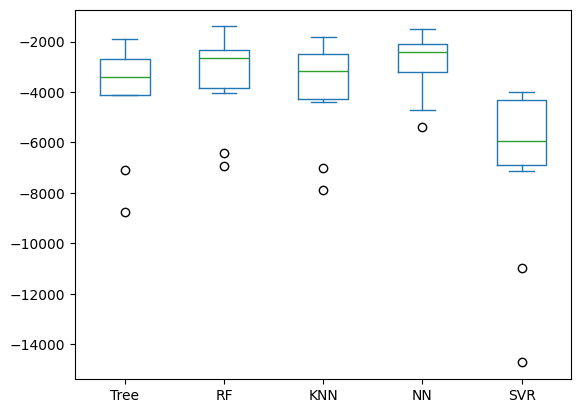

In [ ]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

NN Mejorada

In [ ]:
# ── NN Mejorada (prueba) ─────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor

model_rn2 = MLPRegressor(
    hidden_layer_sizes=(200, 100),  # 2 capas en vez de 1
    activation='relu',
    learning_rate='adaptive',
    learning_rate_init=0.01,        # más conservador que 0.7
    momentum=0.3,
    max_iter=1000,                  # más iteraciones
    verbose=False,
    random_state=42
)

scores_rn2 = cross_validate(model_rn2, X, Y, cv=cv, scoring=scoring,
                             return_train_score=True, return_estimator=False)
scores_rn2 = pd.DataFrame(scores_rn2)

print('scores mean NN Mejorada:')
print(scores_rn2.mean())

scores mean NN Mejorada:
fit_time                                    1.377421e+02
score_time                                  4.062786e-02
test_neg_mean_absolute_error               -2.733631e+03
train_neg_mean_absolute_error              -1.507141e+03
test_neg_mean_squared_error                -2.058259e+07
train_neg_mean_squared_error               -5.807695e+06
test_neg_root_mean_squared_error           -4.038581e+03
train_neg_root_mean_squared_error          -2.406863e+03
test_neg_mean_absolute_percentage_error    -1.386846e-01
train_neg_mean_absolute_percentage_error   -7.417723e-02
dtype: float64


5. Modelo final con todos los datos

In [ ]:
#Desnormalizar para Tree y Random Forest
#X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [ ]:
#Entrenar modelo final con el 100% de los datos
model_rn2.fit(X, Y)

MLPRegressor(hidden_layer_sizes=(200, 100), learning_rate='adaptive',
             learning_rate_init=0.01, max_iter=1000, momentum=0.3,
             random_state=42)

In [ ]:
#Guardar modelo
import pickle

filename = 'modeloNN-carros.pkl'
variables = X.columns.values

pickle.dump([model_rn2, min_max_scaler, variables], open(filename, 'wb'))

print(f'Modelo guardado: {filename}')
print(f'Variables guardadas: {len(variables)} columnas')

Modelo guardado: modeloNN-carros.pkl ✅
Variables guardadas: 80 columnas
